# Étape 6 — Retrieval hybride BM25 + Dense avec RRF

Ce notebook combine les deux baselines déjà validées. Il reconstruit des listes de 100 candidats BM25 et Dense, mesure leur complémentarité, sélectionne une configuration Weighted RRF sur `validation`, puis persiste jusqu'à 50 candidats hybrides par requête pour le futur reranker.

Aucun appel OpenAI n'est effectué ici : les matrices Dense de l'étape 5 sont seulement lues. Le split `test` reste verrouillé.


## 1. Dépendances et environnement


In [1]:
%pip install -q numpy pandas matplotlib scipy


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from __future__ import annotations

import hashlib
import json
import platform
import re
import time
import unicodedata
from datetime import datetime, timezone
from itertools import product
from pathlib import Path
from typing import Any, Iterable, Iterator, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from IPython.display import display
from scipy import sparse

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_colwidth", 140)

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
DATASET_ROOT = PROJECT_ROOT / "data" / "processed" / "multidoc2dial_v1"
CONFIG_PATH = PROJECT_ROOT / "configs" / "hybrid_retrieval_experiments.json"

print(f"Project root : {PROJECT_ROOT}")
print(f"Configuration: {CONFIG_PATH}")
print(f"Python       : {platform.python_version()}")
print(f"NumPy/SciPy : {np.__version__} / {scipy.__version__}")


Project root : C:\Users\dhiar\OneDrive\Bureau\Project\RAG Assistant
Configuration: C:\Users\dhiar\OneDrive\Bureau\Project\RAG Assistant\configs\hybrid_retrieval_experiments.json
Python       : 3.12.7
NumPy/SciPy : 1.26.4 / 1.11.4


## 2. Fonctions de lecture, hash et écriture atomique


In [3]:
def load_json(path: Path) -> dict[str, Any]:
    with path.open(encoding="utf-8") as handle:
        value = json.load(handle)
    if not isinstance(value, dict):
        raise TypeError(f"La racine de {path} doit être un objet JSON")
    return value


def iter_jsonl(path: Path) -> Iterator[dict[str, Any]]:
    with path.open(encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            try:
                yield json.loads(line)
            except json.JSONDecodeError as error:
                raise ValueError(f"JSONL invalide : {path}, ligne {line_number}") from error


def load_jsonl(path: Path) -> list[dict[str, Any]]:
    return list(iter_jsonl(path))


def file_sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        while block := handle.read(1024 * 1024):
            digest.update(block)
    return digest.hexdigest()


def text_sha256(text: str) -> str:
    return hashlib.sha256(text.strip().encode("utf-8")).hexdigest()


def stable_hash(value: Any) -> str:
    payload = json.dumps(value, ensure_ascii=False, sort_keys=True, separators=(",", ":"))
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()


def write_json_atomic(path: Path, value: dict[str, Any] | list[Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + ".tmp")
    temporary.write_text(json.dumps(value, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
    temporary.replace(path)


def write_jsonl_atomic(path: Path, records: Iterable[dict[str, Any]]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + ".tmp")
    with temporary.open("w", encoding="utf-8", newline="\n") as handle:
        for record in records:
            handle.write(json.dumps(record, ensure_ascii=False, separators=(",", ":")))
            handle.write("\n")
    temporary.replace(path)


def artifact_metadata(path: Path, records: int | None = None) -> dict[str, Any]:
    result = {"bytes": path.stat().st_size, "sha256": file_sha256(path)}
    if records is not None:
        result["records"] = records
    return result


def dataframe_records(frame: pd.DataFrame) -> list[dict[str, Any]]:
    return json.loads(frame.to_json(orient="records", double_precision=12))


## 3. Chargement strict des expériences précédentes


In [4]:
config = load_json(CONFIG_PATH)
config_hash = stable_hash(config)
evaluation_split = config["evaluation_split"]
locked_splits = set(config["locked_splits"])
assert evaluation_split == "validation"
assert "test" in locked_splits and evaluation_split not in locked_splits

benchmark_root = DATASET_ROOT / "retrieval_benchmarks" / config["benchmark_id"]
benchmark_manifest_path = benchmark_root / "manifest.json"
benchmark_manifest = load_json(benchmark_manifest_path)
assert benchmark_manifest["quality"]["status"] == "passed"
assert benchmark_manifest["benchmark_id"] == config["benchmark_id"]
validation_path = benchmark_root / "validation.jsonl"
validation_expected = benchmark_manifest["outputs"]["validation.jsonl"]
assert file_sha256(validation_path) == validation_expected["sha256"]
validation_examples = load_jsonl(validation_path)
assert len(validation_examples) == validation_expected["records"]
assert all(item["split"] == "validation" for item in validation_examples)
assert len({item["id"] for item in validation_examples}) == len(validation_examples)

BM25_ROOT = DATASET_ROOT / "bm25_experiments" / config["bm25_experiment_id"]
bm25_manifest_path = BM25_ROOT / "manifest.json"
bm25_manifest = load_json(bm25_manifest_path)
bm25_report_path = PROJECT_ROOT / "reports" / "generated" / "multidoc2dial_v1" / "bm25_experiments" / config["bm25_experiment_id"] / "bm25_report.json"
bm25_report = load_json(bm25_report_path)
assert bm25_manifest["quality"]["status"] == "passed"
assert bm25_manifest["quality"]["test_evaluated"] is False

DENSE_ROOT = DATASET_ROOT / "dense_retrieval_experiments" / config["dense_experiment_id"]
dense_manifest_path = DENSE_ROOT / "manifest.json"
dense_manifest = load_json(dense_manifest_path)
dense_report_path = PROJECT_ROOT / "reports" / "generated" / "multidoc2dial_v1" / "dense_retrieval_experiments" / config["dense_experiment_id"] / "dense_report.json"
dense_report = load_json(dense_report_path)
assert dense_manifest["quality"]["status"] == "passed"
assert dense_manifest["quality"]["test_split_loaded"] is False
assert dense_manifest["embedding"]["normalized_l2"] is True

assert set(config["strategies"]) == set(bm25_manifest["selected_parameters_by_strategy"])
assert set(config["strategies"]) == set(dense_manifest["vector_artifacts"]["strategies"])

experiment_fingerprint = stable_hash({
    "configuration": config, "benchmark_manifest_sha256": file_sha256(benchmark_manifest_path),
    "validation_sha256": validation_expected["sha256"],
    "bm25_manifest_sha256": file_sha256(bm25_manifest_path),
    "dense_manifest_sha256": file_sha256(dense_manifest_path),
})
experiment_id = f"{config['experiment_name']}_{experiment_fingerprint[:10]}"
OUTPUT_ROOT = DATASET_ROOT / "hybrid_retrieval_experiments" / experiment_id
REPORT_ROOT = PROJECT_ROOT / "reports" / "generated" / "multidoc2dial_v1" / "hybrid_retrieval_experiments" / experiment_id

print(f"Validation chargée : {len(validation_examples):,} exemples")
print(f"Split test chargé  : {False}")
print(f"BM25 source        : {config['bm25_experiment_id']}")
print(f"Dense source       : {config['dense_experiment_id']}")
print(f"Experiment ID      : {experiment_id}")


Validation chargée : 4,699 exemples
Split test chargé  : False
BM25 source        : bm25_retrieval_baseline_v1_8def866155
Dense source       : openai_dense_retrieval_v1_3b9e048ba8
Experiment ID      : hybrid_rrf_retrieval_v1_a91b993d86


## 4. Questions uniques et matrice Dense

Les rankings sont calculés une seule fois par texte de question unique, puis réutilisés pour tous les exemples qui portent exactement ce texte.


In [5]:
query_text_by_hash: dict[str, str] = {}
query_hash_by_example: dict[str, str] = {}
for example in validation_examples:
    text_hash = text_sha256(example["query"]["text"])
    text = example["query"]["text"].strip()
    previous = query_text_by_hash.setdefault(text_hash, text)
    assert previous == text, "Collision de hash entre deux questions"
    query_hash_by_example[example["id"]] = text_hash

query_hashes = sorted(query_text_by_hash)
query_texts = [query_text_by_hash[text_hash] for text_hash in query_hashes]
unique_query_position = {text_hash: position for position, text_hash in enumerate(query_hashes)}
example_query_positions = [unique_query_position[query_hash_by_example[item["id"]]] for item in validation_examples]

dense_query_vectors_path = DENSE_ROOT / "vectors" / "query_vectors.npy"
dense_query_index_path = DENSE_ROOT / "vectors" / "query_index.json"
query_vector_meta = dense_manifest["vector_artifacts"]["queries"]["query_vectors.npy"]
query_index_meta = dense_manifest["vector_artifacts"]["queries"]["query_index.json"]
assert file_sha256(dense_query_vectors_path) == query_vector_meta["sha256"]
assert file_sha256(dense_query_index_path) == query_index_meta["sha256"]
dense_query_index = load_json(dense_query_index_path)
dense_query_row = {text_hash: row for row, text_hash in enumerate(dense_query_index["text_hashes"])}
missing_query_hashes = set(query_hashes) - set(dense_query_row)
assert not missing_query_hashes, f"{len(missing_query_hashes)} questions absentes de l'étape Dense"
all_query_vectors = np.load(dense_query_vectors_path, mmap_mode="r", allow_pickle=False)
validation_query_vectors = np.asarray(
    all_query_vectors[[dense_query_row[text_hash] for text_hash in query_hashes]], dtype=np.float32,
)
assert np.isfinite(validation_query_vectors).all()
assert np.allclose(np.linalg.norm(validation_query_vectors, axis=1), 1.0, atol=1e-5)
print(f"Questions validation       : {len(validation_examples):,}")
print(f"Textes de question uniques: {len(query_hashes):,}")
print(f"Matrice requêtes Dense    : {validation_query_vectors.shape}")


Questions validation       : 4,699
Textes de question uniques: 3,763
Matrice requêtes Dense    : (3763, 1536)


## 5. Reconstruction déterministe des deux moteurs


In [6]:
class PersistedBM25Index:
    def __init__(self, strategy: str):
        self.strategy = strategy
        root = BM25_ROOT / "indexes" / strategy
        matrix_path = root / "tf_matrix.npz"
        metadata_path = root / "index_metadata.json"
        expected = bm25_manifest["artifacts_by_strategy"][strategy]["index"]
        assert file_sha256(matrix_path) == expected["tf_matrix.npz"]["sha256"]
        assert file_sha256(metadata_path) == expected["index_metadata.json"]["sha256"]
        metadata = load_json(metadata_path)
        assert metadata["strategy"] == strategy
        self.tf_matrix = sparse.load_npz(matrix_path).tocsr().astype(np.float32)
        self.chunk_ids = np.asarray(metadata["chunk_ids"], dtype=str)
        self.document_lengths = np.asarray(metadata["document_lengths"], dtype=np.float32)
        self.vocabulary = metadata["vocabulary"]
        self.term_to_id = {term: index for index, term in enumerate(self.vocabulary)}
        self.analyzer = metadata["analyzer"]
        self.pattern = re.compile(self.analyzer["token_pattern"], flags=re.UNICODE)
        assert self.tf_matrix.shape == (len(self.chunk_ids), len(self.vocabulary))
        assert len(self.document_lengths) == len(self.chunk_ids)
        document_frequency = np.asarray((self.tf_matrix > 0).sum(axis=0)).ravel()
        document_count = self.tf_matrix.shape[0]
        self.idf = np.log(1.0 + (document_count - document_frequency + 0.5) / (document_frequency + 0.5)).astype(np.float32)

    def analyze(self, text: str) -> list[str]:
        value = unicodedata.normalize(self.analyzer["unicode_normalization"], text)
        if self.analyzer["casefold"]:
            value = value.casefold()
        return self.pattern.findall(value)

    def impact_matrix(self, k1: float, b: float) -> sparse.csr_matrix:
        row_ids = np.repeat(np.arange(self.tf_matrix.shape[0]), np.diff(self.tf_matrix.indptr))
        frequencies = self.tf_matrix.data.astype(np.float32, copy=False)
        average_length = float(self.document_lengths.mean())
        length_factor = k1 * (1.0 - b + b * self.document_lengths[row_ids] / average_length)
        weights = (self.idf[self.tf_matrix.indices] * frequencies * (k1 + 1.0) / (frequencies + length_factor)).astype(np.float32)
        weighted = sparse.csr_matrix(
            (weights, self.tf_matrix.indices.copy(), self.tf_matrix.indptr.copy()), shape=self.tf_matrix.shape,
        )
        impact = weighted.transpose().tocsr()
        impact.sort_indices()
        return impact

    def encode_queries(self, texts: Sequence[str]) -> sparse.csr_matrix:
        rows, columns = [], []
        for row, text in enumerate(texts):
            tokens = self.analyze(text)
            if self.analyzer["unique_query_terms"]:
                tokens = sorted(set(tokens))
            for token in tokens:
                term_id = self.term_to_id.get(token)
                if term_id is not None:
                    rows.append(row)
                    columns.append(term_id)
        values = np.ones(len(rows), dtype=np.float32)
        matrix = sparse.csr_matrix((values, (rows, columns)), shape=(len(texts), len(self.vocabulary)), dtype=np.float32)
        matrix.sum_duplicates()
        return matrix

    def rank_sparse_row(self, document_ids: np.ndarray, scores: np.ndarray, depth: int) -> list[tuple[str, float]]:
        positive = scores > 0
        document_ids, scores = document_ids[positive], scores[positive]
        if not len(document_ids):
            return []
        if len(document_ids) > depth:
            threshold = np.partition(scores, len(scores) - depth)[len(scores) - depth]
            keep = scores >= threshold
            document_ids, scores = document_ids[keep], scores[keep]
        chunk_ids = self.chunk_ids[document_ids]
        order = np.lexsort((chunk_ids, -scores))[:depth]
        return [(str(chunk_ids[position]), float(scores[position])) for position in order]

    def search_many(self, texts: Sequence[str], depth: int, batch_size: int) -> tuple[list[list[tuple[str, float]]], float]:
        parameters = bm25_manifest["selected_parameters_by_strategy"][self.strategy]
        impact = self.impact_matrix(parameters["k1"], parameters["b"])
        queries = self.encode_queries(texts)
        rankings = []
        started = time.perf_counter()
        for start in range(0, len(texts), batch_size):
            scores = (queries[start:start + batch_size] @ impact).tocsr()
            for row in range(scores.shape[0]):
                left, right = scores.indptr[row], scores.indptr[row + 1]
                rankings.append(self.rank_sparse_row(scores.indices[left:right], scores.data[left:right], depth))
        return rankings, time.perf_counter() - started


In [7]:
def rank_dense_row(scores: np.ndarray, chunk_ids: np.ndarray, depth: int) -> list[tuple[str, float]]:
    if not np.isfinite(scores).all():
        raise ValueError("Score Dense non fini")
    if scores.size > depth:
        positions = np.argpartition(scores, -depth)[-depth:]
        threshold = scores[positions].min()
        candidates = np.flatnonzero(scores >= threshold)
    else:
        candidates = np.arange(scores.size)
    order = np.lexsort((chunk_ids[candidates], -scores[candidates]))[:depth]
    chosen = candidates[order]
    return [(str(chunk_ids[position]), float(scores[position])) for position in chosen]


def dense_search_many(
    query_vectors: np.ndarray, chunk_vectors: np.ndarray, chunk_ids: np.ndarray, depth: int, batch_size: int,
) -> tuple[list[list[tuple[str, float]]], float]:
    rankings = []
    started = time.perf_counter()
    for start in range(0, len(query_vectors), batch_size):
        scores = query_vectors[start:start + batch_size] @ chunk_vectors.T
        rankings.extend(rank_dense_row(row, chunk_ids, depth) for row in scores)
    return rankings, time.perf_counter() - started


## 6. RRF, métriques et analyse de complémentarité


In [8]:
TOP_K_VALUES = sorted(config["evaluation"]["top_k_values"])
MAX_K = max(TOP_K_VALUES)

def fuse_rrf(
    bm25_ranking: list[tuple[str, float]], dense_ranking: list[tuple[str, float]],
    candidate_depth: int, rank_constant: int, bm25_weight: float, dense_weight: float, output_depth: int,
) -> list[dict[str, Any]]:
    candidates: dict[str, dict[str, Any]] = {}
    for source, ranking, weight in (("bm25", bm25_ranking, bm25_weight), ("dense", dense_ranking, dense_weight)):
        for rank, (chunk_id, raw_score) in enumerate(ranking[:candidate_depth], start=1):
            item = candidates.setdefault(chunk_id, {
                "chunk_id": chunk_id, "rrf_score": 0.0,
                "bm25_rank": None, "dense_rank": None, "bm25_score": None, "dense_score": None,
            })
            item["rrf_score"] += weight / (rank_constant + rank)
            item[f"{source}_rank"] = rank
            item[f"{source}_score"] = raw_score
    ordered = sorted(
        candidates.values(),
        key=lambda item: (-item["rrf_score"], min(item["bm25_rank"] or 10**9, item["dense_rank"] or 10**9), item["chunk_id"]),
    )
    return ordered[:output_depth]


def fuse_many(
    bm25_rankings: list[list[tuple[str, float]]], dense_rankings: list[list[tuple[str, float]]],
    parameters: dict[str, Any], output_depth: int,
) -> list[list[dict[str, Any]]]:
    return [
        fuse_rrf(bm25, dense, parameters["candidate_depth"], parameters["rank_constant"],
                 parameters["bm25_weight"], parameters["dense_weight"], output_depth)
        for bm25, dense in zip(bm25_rankings, dense_rankings)
    ]


def binary_ndcg(ranked_ids: list[str], relevant_ids: set[str], k: int) -> float:
    gains = [1.0 if chunk_id in relevant_ids else 0.0 for chunk_id in ranked_ids[:k]]
    dcg = sum(gain / np.log2(rank + 2.0) for rank, gain in enumerate(gains))
    ideal_count = min(len(relevant_ids), k)
    if ideal_count == 0:
        return 0.0
    ideal = sum(1.0 / np.log2(rank + 2.0) for rank in range(ideal_count))
    return float(dcg / ideal)


def score_rankings(
    examples: list[dict[str, Any]], rankings: list[list[tuple[str, float]]], strategy: str, run: str,
    chunk_spans: dict[str, frozenset[str]],
) -> pd.DataFrame:
    assert len(examples) == len(rankings)
    rows = []
    known_chunks = set(chunk_spans)
    for example, ranking in zip(examples, rankings):
        ranked_ids = [chunk_id for chunk_id, _ in ranking]
        gold_spans = set(example["gold"]["span_ids"])
        relevant_ids = set(example["strategy_ground_truth"][strategy]["relevant_chunk_ids"])
        assert relevant_ids <= known_chunks and set(ranked_ids) <= known_chunks
        first_rank = next((rank for rank, chunk_id in enumerate(ranked_ids[:MAX_K], 1) if chunk_id in relevant_ids), None)
        row = {
            "example_id": example["id"], "split": example["split"], "domain": example["domain"],
            "cohort": example["cohort"], "is_short_query": bool(example["query"]["is_short"]),
            "exact_text_overlap_free": bool(example["diagnostics"]["exact_text_overlap_free"]),
            "strategy": strategy, "run": run, "returned_chunks": len(ranked_ids),
            "zero_result": not ranked_ids, f"mrr@{MAX_K}": 1.0 / first_rank if first_rank else 0.0,
        }
        for k in TOP_K_VALUES:
            covered = set()
            for chunk_id in ranked_ids[:k]:
                covered.update(chunk_spans[chunk_id] & gold_spans)
            row[f"evidence_recall@{k}"] = len(covered) / len(gold_spans)
            row[f"any_evidence_hit@{k}"] = float(bool(covered))
            row[f"all_evidence_hit@{k}"] = float(covered == gold_spans)
            row[f"chunk_ndcg@{k}"] = binary_ndcg(ranked_ids, relevant_ids, k)
        rows.append(row)
    return pd.DataFrame(rows)


def quick_primary_metrics(
    fused_unique: list[list[dict[str, Any]]], strategy: str, chunk_spans: dict[str, frozenset[str]],
) -> dict[str, float]:
    recall5 = all5 = mrr10 = ndcg10 = 0.0
    count = 0
    for example, query_position in zip(validation_examples, example_query_positions):
        if example["cohort"] != config["evaluation"]["primary_cohort"]:
            continue
        ranked_ids = [item["chunk_id"] for item in fused_unique[query_position]][:MAX_K]
        gold_spans = set(example["gold"]["span_ids"])
        relevant_ids = set(example["strategy_ground_truth"][strategy]["relevant_chunk_ids"])
        covered = set()
        for chunk_id in ranked_ids[:5]:
            covered.update(chunk_spans[chunk_id] & gold_spans)
        first_rank = next((rank for rank, chunk_id in enumerate(ranked_ids, 1) if chunk_id in relevant_ids), None)
        recall5 += len(covered) / len(gold_spans)
        all5 += float(covered == gold_spans)
        mrr10 += 1.0 / first_rank if first_rank else 0.0
        ndcg10 += binary_ndcg(ranked_ids, relevant_ids, MAX_K)
        count += 1
    return {
        "queries": count, "evidence_recall@5": recall5 / count, "all_evidence_hit@5": all5 / count,
        f"mrr@{MAX_K}": mrr10 / count, f"chunk_ndcg@{MAX_K}": ndcg10 / count,
    }


def slice_masks(frame: pd.DataFrame) -> dict[str, pd.Series]:
    primary = frame["cohort"] == config["evaluation"]["primary_cohort"]
    return {
        "all_examples": pd.Series(True, index=frame.index),
        "official_primary": primary,
        "overlap_free_primary": primary & frame["exact_text_overlap_free"],
        "short_query_primary": primary & frame["is_short_query"],
        "non_short_query_primary": primary & ~frame["is_short_query"],
        "agent_continuation": frame["cohort"] == "agent_continuation",
    }


METRIC_COLUMNS = [f"{name}@{k}" for k in TOP_K_VALUES for name in ("evidence_recall", "any_evidence_hit", "all_evidence_hit", "chunk_ndcg")] + [f"mrr@{MAX_K}"]

def summarize_metrics(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for slice_name, mask in slice_masks(frame).items():
        subset = frame[mask]
        if subset.empty:
            continue
        row = {
            "strategy": subset["strategy"].iloc[0], "run": subset["run"].iloc[0],
            "split": "validation", "slice": slice_name, "queries": len(subset),
            "zero_result_rate": float(subset["zero_result"].mean()),
            "mean_returned_chunks": float(subset["returned_chunks"].mean()),
        }
        row.update({column: float(subset[column].mean()) for column in METRIC_COLUMNS})
        rows.append(row)
    return pd.DataFrame(rows)


def summarize_by_domain(frame: pd.DataFrame) -> pd.DataFrame:
    primary = frame[frame["cohort"] == config["evaluation"]["primary_cohort"]]
    columns = ["evidence_recall@1", "evidence_recall@5", "all_evidence_hit@5", f"mrr@{MAX_K}"]
    result = primary.groupby("domain", as_index=False)[columns].mean()
    result.insert(0, "strategy", frame["strategy"].iloc[0])
    result.insert(1, "run", frame["run"].iloc[0])
    result.insert(2, "split", "validation")
    return result


In [9]:
def complementarity_summary(
    bm25_unique: list[list[tuple[str, float]]], dense_unique: list[list[tuple[str, float]]],
    chunk_spans: dict[str, frozenset[str]],
) -> dict[str, Any]:
    jaccard10, jaccard50 = [], []
    span_categories = {"both": 0, "bm25_only": 0, "dense_only": 0, "neither": 0}
    union_covered = {depth: 0 for depth in config["fusion"]["candidate_depth_values"]}
    total_spans = 0
    for example, position in zip(validation_examples, example_query_positions):
        if example["cohort"] != config["evaluation"]["primary_cohort"]:
            continue
        bm25_ids = [item[0] for item in bm25_unique[position]]
        dense_ids = [item[0] for item in dense_unique[position]]
        for depth, target in ((10, jaccard10), (50, jaccard50)):
            left, right = set(bm25_ids[:depth]), set(dense_ids[:depth])
            target.append(len(left & right) / len(left | right) if left | right else 1.0)
        gold = set(example["gold"]["span_ids"])
        bm25_spans, dense_spans = set(), set()
        for chunk_id in bm25_ids[:10]:
            bm25_spans.update(chunk_spans[chunk_id] & gold)
        for chunk_id in dense_ids[:10]:
            dense_spans.update(chunk_spans[chunk_id] & gold)
        for span_id in gold:
            in_bm25, in_dense = span_id in bm25_spans, span_id in dense_spans
            category = "both" if in_bm25 and in_dense else "bm25_only" if in_bm25 else "dense_only" if in_dense else "neither"
            span_categories[category] += 1
        for depth in union_covered:
            covered = set()
            for chunk_id in set(bm25_ids[:depth]) | set(dense_ids[:depth]):
                covered.update(chunk_spans[chunk_id] & gold)
            union_covered[depth] += len(covered)
        total_spans += len(gold)
    return {
        "queries": len(jaccard10), "mean_top10_jaccard": float(np.mean(jaccard10)),
        "mean_top50_jaccard": float(np.mean(jaccard50)), "gold_span_counts_at_top10": span_categories,
        "gold_span_rates_at_top10": {key: value / total_spans for key, value in span_categories.items()},
        "candidate_union_evidence_recall": {str(depth): union_covered[depth] / total_spans for depth in union_covered},
        "total_gold_spans": total_spans,
    }


## 7. Génération top-100, grille RRF et sélection


In [10]:
maximum_depth = config["candidate_generation"]["maximum_depth"]
batch_size = config["candidate_generation"]["query_batch_size"]
persisted_depth = config["fusion"]["persisted_candidate_depth"]
grid_parameters = [
    {"candidate_depth": depth, "rank_constant": constant, "bm25_weight": bm25_weight, "dense_weight": 1.0 - bm25_weight}
    for depth, constant, bm25_weight in product(
        config["fusion"]["candidate_depth_values"], config["fusion"]["rank_constant_values"],
        config["fusion"]["bm25_weight_values"],
    )
]
rng = np.random.default_rng(config["performance"]["random_seed"])
latency_sample_size = min(config["performance"]["latency_sample_size"], len(query_hashes))
latency_sample_positions = rng.choice(len(query_hashes), size=latency_sample_size, replace=False)
latency_warmup = min(config["performance"]["latency_warmup_queries"], latency_sample_size)
print(f"Configurations RRF par stratégie : {len(grid_parameters)}")

all_metric_frames, all_summary_frames, all_domain_frames = [], [], []
grid_records, complementarity_records, performance_records = [], [], []
selected_parameters: dict[str, dict[str, Any]] = {}
ranking_artifacts: dict[str, dict[str, Any]] = {}
baseline_parity_records = []

bm25_reference = pd.DataFrame(bm25_report["metrics_summary"])
dense_metrics_path = dense_report_path.parent / "metrics_summary.json"
assert file_sha256(dense_metrics_path) == dense_manifest["report_outputs"]["metrics_summary.json"]["sha256"]
dense_reference = pd.DataFrame(json.loads(dense_metrics_path.read_text(encoding="utf-8")))

for strategy in config["strategies"]:
    print(f"\n--- {strategy} ---")
    bm25_index = PersistedBM25Index(strategy)
    dense_strategy_root = DENSE_ROOT / "vectors" / strategy
    dense_vectors_path = dense_strategy_root / "chunk_vectors.npy"
    dense_index_path = dense_strategy_root / "chunk_index.json"
    dense_expected = dense_manifest["vector_artifacts"]["strategies"][strategy]
    assert file_sha256(dense_vectors_path) == dense_expected["chunk_vectors.npy"]["sha256"]
    assert file_sha256(dense_index_path) == dense_expected["chunk_index.json"]["sha256"]
    dense_index = load_json(dense_index_path)
    dense_chunk_ids = np.asarray([item["chunk_id"] for item in dense_index["chunks"]], dtype=str)
    dense_chunk_vectors = np.load(dense_vectors_path, mmap_mode="r", allow_pickle=False)
    assert dense_chunk_vectors.shape[0] == len(dense_chunk_ids)
    assert set(dense_chunk_ids.tolist()) == set(bm25_index.chunk_ids.tolist())
    chunk_spans = {item["chunk_id"]: frozenset(item["source_span_ids"]) for item in dense_index["chunks"]}

    bm25_unique, bm25_seconds = bm25_index.search_many(query_texts, maximum_depth, batch_size)
    dense_unique, dense_seconds = dense_search_many(
        validation_query_vectors, dense_chunk_vectors, dense_chunk_ids, maximum_depth, batch_size,
    )
    assert len(bm25_unique) == len(dense_unique) == len(query_hashes)
    performance_records.extend([
        {"strategy": strategy, "measurement": "bm25_top100_unique_queries", "queries": len(query_hashes), "seconds": bm25_seconds},
        {"strategy": strategy, "measurement": "dense_top100_unique_queries", "queries": len(query_hashes), "seconds": dense_seconds},
    ])
    complementarity = complementarity_summary(bm25_unique, dense_unique, chunk_spans)
    complementarity_records.append({"strategy": strategy, **complementarity})

    tuning_started = time.perf_counter()
    strategy_grid = []
    for parameters in grid_parameters:
        fused_unique = fuse_many(bm25_unique, dense_unique, parameters, MAX_K)
        metrics = quick_primary_metrics(fused_unique, strategy, chunk_spans)
        record = {"strategy": strategy, **parameters, **metrics}
        record["weight_balance"] = -abs(parameters["bm25_weight"] - 0.5)
        record["lower_candidate_depth"] = -parameters["candidate_depth"]
        record["standard_rrf_constant"] = -abs(parameters["rank_constant"] - 60)
        strategy_grid.append(record)
        grid_records.append(record)
    strategy_grid_df = pd.DataFrame(strategy_grid).sort_values(
        ["evidence_recall@5", f"mrr@{MAX_K}", "all_evidence_hit@5", f"chunk_ndcg@{MAX_K}",
         "weight_balance", "lower_candidate_depth", "standard_rrf_constant"],
        ascending=[False, False, False, False, False, False, False], kind="mergesort",
    )
    selected = strategy_grid_df.iloc[0]
    parameters = {key: int(selected[key]) if key in ("candidate_depth", "rank_constant") else float(selected[key])
                  for key in ("candidate_depth", "rank_constant", "bm25_weight", "dense_weight")}
    selected_parameters[strategy] = parameters
    performance_records.append({
        "strategy": strategy, "measurement": "rrf_grid_search", "configurations": len(strategy_grid),
        "seconds": time.perf_counter() - tuning_started,
    })

    selected_unique = fuse_many(bm25_unique, dense_unique, parameters, persisted_depth)
    for position in latency_sample_positions[:latency_warmup]:
        fuse_rrf(bm25_unique[position], dense_unique[position], parameters["candidate_depth"],
                 parameters["rank_constant"], parameters["bm25_weight"], parameters["dense_weight"], persisted_depth)
    fusion_latencies_ms = []
    for position in latency_sample_positions:
        latency_started = time.perf_counter()
        fuse_rrf(bm25_unique[position], dense_unique[position], parameters["candidate_depth"],
                 parameters["rank_constant"], parameters["bm25_weight"], parameters["dense_weight"], persisted_depth)
        fusion_latencies_ms.append((time.perf_counter() - latency_started) * 1000)
    performance_records.append({
        "strategy": strategy, "measurement": "single_query_selected_rrf_fusion_compute_only",
        "queries": latency_sample_size, "mean_ms": float(np.mean(fusion_latencies_ms)),
        "p50_ms": float(np.quantile(fusion_latencies_ms, 0.50)),
        "p95_ms": float(np.quantile(fusion_latencies_ms, 0.95)),
        "p99_ms": float(np.quantile(fusion_latencies_ms, 0.99)),
    })
    bm25_examples = [bm25_unique[position][:MAX_K] for position in example_query_positions]
    dense_examples = [dense_unique[position][:MAX_K] for position in example_query_positions]
    hybrid_examples_detailed = [selected_unique[position] for position in example_query_positions]
    hybrid_examples = [[(item["chunk_id"], item["rrf_score"]) for item in ranking[:MAX_K]] for ranking in hybrid_examples_detailed]

    frames = [
        score_rankings(validation_examples, bm25_examples, strategy, "bm25_tuned", chunk_spans),
        score_rankings(validation_examples, dense_examples, strategy, "dense_openai_exact", chunk_spans),
        score_rankings(validation_examples, hybrid_examples, strategy, "hybrid_selected", chunk_spans),
    ]
    for frame in frames:
        all_metric_frames.append(frame)
        all_summary_frames.append(summarize_metrics(frame))
        all_domain_frames.append(summarize_by_domain(frame))

    primary_rows = {run: frame[(frame["cohort"] == config["evaluation"]["primary_cohort"])][["evidence_recall@1", "evidence_recall@5", "evidence_recall@10", f"mrr@{MAX_K}"]].mean()
                    for run, frame in zip(("bm25_tuned", "dense_openai_exact", "hybrid_selected"), frames)}
    bm25_ref = bm25_reference[(bm25_reference["strategy"] == strategy) & (bm25_reference["split"] == "validation") &
                               (bm25_reference["slice"] == "official_primary") & (bm25_reference["run"] == "tuned_validation")].iloc[0]
    dense_ref = dense_reference[(dense_reference["strategy"] == strategy) & (dense_reference["split"] == "validation") &
                               (dense_reference["slice"] == "official_primary")].iloc[0]
    for run, current, reference in (("bm25_tuned", primary_rows["bm25_tuned"], bm25_ref),
                                    ("dense_openai_exact", primary_rows["dense_openai_exact"], dense_ref)):
        for metric in ("evidence_recall@1", "evidence_recall@5", "evidence_recall@10", f"mrr@{MAX_K}"):
            baseline_parity_records.append({
                "strategy": strategy, "run": run, "metric": metric, "current": float(current[metric]),
                "reference": float(reference[metric]), "absolute_difference": abs(float(current[metric]) - float(reference[metric])),
            })

    rankings_path = OUTPUT_ROOT / "rankings" / strategy / "selected_hybrid_validation.jsonl"
    def ranking_records() -> Iterator[dict[str, Any]]:
        for example, candidates in zip(validation_examples, hybrid_examples_detailed):
            yield {
                "schema_version": "1.0.0", "experiment_id": experiment_id, "example_id": example["id"],
                "split": "validation", "cohort": example["cohort"], "strategy": strategy,
                "run": "hybrid_selected", "parameters": parameters, "candidates": candidates,
            }
    write_jsonl_atomic(rankings_path, ranking_records())
    ranking_artifacts[strategy] = artifact_metadata(rankings_path, len(validation_examples))
    print(f"Sélection : {parameters} — Recall@5={selected['evidence_recall@5']:.4f}")

metrics_frame = pd.concat(all_metric_frames, ignore_index=True)
summary_df = pd.concat(all_summary_frames, ignore_index=True)
domain_df = pd.concat(all_domain_frames, ignore_index=True)
grid_df = pd.DataFrame(grid_records)
complementarity_df = pd.DataFrame(complementarity_records)
performance_df = pd.DataFrame(performance_records)
baseline_parity_df = pd.DataFrame(baseline_parity_records)


Configurations RRF par stratégie : 45

--- fixed_v1 ---
Sélection : {'candidate_depth': 100, 'rank_constant': 10, 'bm25_weight': 0.5, 'dense_weight': 0.5} — Recall@5=0.4887

--- structure_aware_v1 ---
Sélection : {'candidate_depth': 100, 'rank_constant': 10, 'bm25_weight': 0.5, 'dense_weight': 0.5} — Recall@5=0.4736

--- section_preserving_v1 ---
Sélection : {'candidate_depth': 100, 'rank_constant': 10, 'bm25_weight': 0.5, 'dense_weight': 0.5} — Recall@5=0.5078

--- hierarchical_v1 ---
Sélection : {'candidate_depth': 100, 'rank_constant': 10, 'bm25_weight': 0.5, 'dense_weight': 0.5} — Recall@5=0.4759


## 8. Résultats à examiner


Validation officielle — Evidence Recall@5


run,bm25_tuned,dense_openai_exact,hybrid_selected,gain_vs_best_baseline
strategy,,,,
section_preserving_v1,0.4637,0.4333,0.5078,0.0440
fixed_v1,0.4281,0.4368,0.4887,0.0519
hierarchical_v1,0.4325,0.4174,0.4759,0.0434
structure_aware_v1,0.4322,0.4188,0.4736,0.0414


Paramètres sélectionnés


,strategy,candidate_depth,rank_constant,bm25_weight,dense_weight
0,fixed_v1,100,10,0.5,0.5
1,structure_aware_v1,100,10,0.5,0.5
2,section_preserving_v1,100,10,0.5,0.5
3,hierarchical_v1,100,10,0.5,0.5


Complémentarité BM25 / Dense


,strategy,mean_top10_jaccard,mean_top50_jaccard,gold_span_rates_at_top10,candidate_union_evidence_recall
0,fixed_v1,0.196804,0.211652,"{'both': 0.4237571368890127, 'bm25_only': 0.09692243420136472, 'dense_only': 0.1150257624286311, 'neither': 0.3642946664809915}","{'20': 0.6989277259434619, '50': 0.7753794736109177, '100': 0.8223088706308314}"
1,structure_aware_v1,0.214878,0.206650,"{'both': 0.4057930650327252, 'bm25_only': 0.10472079097618717, 'dense_only': 0.11196212226709372, 'neither': 0.37752402172399385}","{'20': 0.6823562177969642, '50': 0.758947221835399, '100': 0.8072691825651024}"
2,section_preserving_v1,0.214763,0.233586,"{'both': 0.4467344381005431, 'bm25_only': 0.10764517476674558, 'dense_only': 0.09511210137863807, 'neither': 0.3505082857540732}","{'20': 0.7110430302186325, '50': 0.7834563431276981, '100': 0.8440328645035511}"
3,hierarchical_v1,0.208349,0.203446,"{'both': 0.40119760479041916, 'bm25_only': 0.10486004734716613, 'dense_only': 0.11321542960590447, 'neither': 0.3807269182565102}","{'20': 0.6791533212644478, '50': 0.7556050689319036, '100': 0.8026737223227962}"


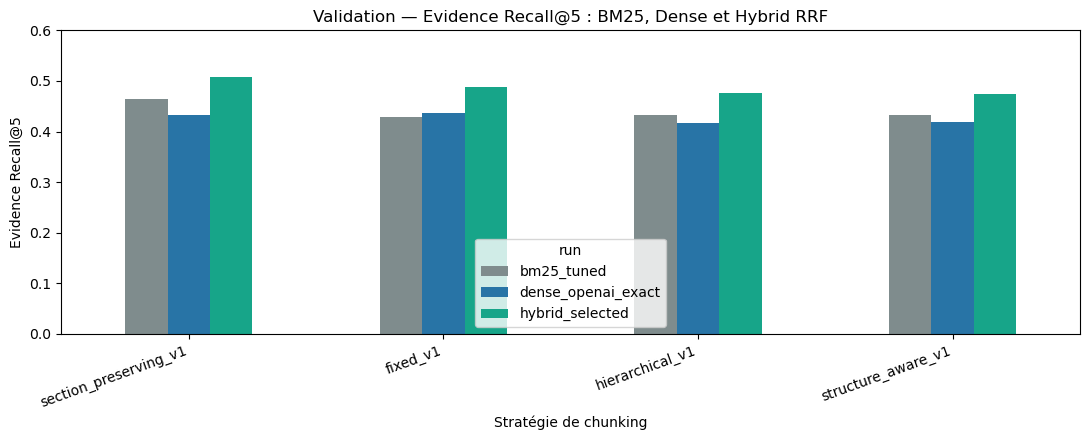

Meilleure stratégie Hybrid sur validation : section_preserving_v1 (0.5078)


In [11]:
primary_comparison = summary_df[(summary_df["slice"] == "official_primary")][
    ["strategy", "run", "queries", "evidence_recall@1", "evidence_recall@5", "evidence_recall@10", f"mrr@{MAX_K}", "all_evidence_hit@5"]
].copy()
pivot = primary_comparison.pivot(index="strategy", columns="run", values="evidence_recall@5")
pivot["gain_vs_best_baseline"] = pivot["hybrid_selected"] - pivot[["bm25_tuned", "dense_openai_exact"]].max(axis=1)
pivot = pivot.sort_values("hybrid_selected", ascending=False)
print("Validation officielle — Evidence Recall@5")
display(pivot.round(4))

selected_table = pd.DataFrame([{"strategy": strategy, **parameters} for strategy, parameters in selected_parameters.items()])
print("Paramètres sélectionnés")
display(selected_table)

complementarity_display = complementarity_df[["strategy", "mean_top10_jaccard", "mean_top50_jaccard",
                                                   "gold_span_rates_at_top10", "candidate_union_evidence_recall"]]
print("Complémentarité BM25 / Dense")
display(complementarity_display)

ax = pivot[["bm25_tuned", "dense_openai_exact", "hybrid_selected"]].plot(
    kind="bar", figsize=(11, 4.5), color=["#7f8c8d", "#2874a6", "#17a589"],
)
ax.set_title("Validation — Evidence Recall@5 : BM25, Dense et Hybrid RRF")
ax.set_ylabel("Evidence Recall@5")
ax.set_xlabel("Stratégie de chunking")
ax.set_ylim(0, max(0.6, float(pivot[["bm25_tuned", "dense_openai_exact", "hybrid_selected"]].max().max()) + 0.05))
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

best_strategy = str(pivot.index[0])
print(f"Meilleure stratégie Hybrid sur validation : {best_strategy} ({pivot.loc[best_strategy, 'hybrid_selected']:.4f})")


## 9. Quality gates et latence de fusion


In [12]:
fusion_latency_rows = performance_df[performance_df["measurement"] == "single_query_selected_rrf_fusion_compute_only"]
if len(fusion_latency_rows) != len(config["strategies"]) or fusion_latency_rows[["mean_ms", "p95_ms", "p99_ms"]].isna().any().any():
    quality_errors = ["Mesures de latence RRF incomplètes"]
else:
    quality_errors = []
estimated_fusion_operations = len(config["strategies"]) * len(grid_parameters) * len(query_hashes)
print(f"Fusions de rankings évaluées pendant la grille : {estimated_fusion_operations:,}")
display(fusion_latency_rows[["strategy", "queries", "mean_ms", "p50_ms", "p95_ms", "p99_ms"]].round(4))

quality_warnings = []
if evaluation_split in locked_splits or "test" not in locked_splits:
    quality_errors.append("Contrat de split invalide")
if metrics_frame.empty or summary_df.empty or grid_df.empty:
    quality_errors.append("Résultats expérimentaux vides")
if metrics_frame[METRIC_COLUMNS].isna().any().any():
    quality_errors.append("Métriques NaN")
if not ((metrics_frame[METRIC_COLUMNS] >= 0) & (metrics_frame[METRIC_COLUMNS] <= 1)).all().all():
    quality_errors.append("Métriques hors de [0, 1]")
expected_grid_rows = len(config["strategies"]) * len(grid_parameters)
if len(grid_df) != expected_grid_rows:
    quality_errors.append(f"Grille incomplète : {len(grid_df)} / {expected_grid_rows}")
if set(selected_parameters) != set(config["strategies"]):
    quality_errors.append("Paramètres sélectionnés manquants")
max_parity_difference = float(baseline_parity_df["absolute_difference"].max())
parity_tolerance = config["evaluation"]["baseline_parity_tolerance"]
if max_parity_difference > parity_tolerance:
    quality_errors.append(f"Baselines hors tolérance numérique : écart {max_parity_difference} > {parity_tolerance}")
for strategy in config["strategies"]:
    path = OUTPUT_ROOT / "rankings" / strategy / "selected_hybrid_validation.jsonl"
    count = 0
    for record in iter_jsonl(path):
        count += 1
        candidates = record["candidates"]
        ids = [item["chunk_id"] for item in candidates]
        scores = [item["rrf_score"] for item in candidates]
        if len(ids) < MAX_K or len(ids) != len(set(ids)):
            quality_errors.append(f"Ranking invalide : {strategy} / {record['example_id']}")
            break
        if any(scores[index] < scores[index + 1] for index in range(len(scores) - 1)):
            quality_errors.append(f"Scores RRF non triés : {strategy} / {record['example_id']}")
            break
        if any(item["bm25_rank"] is None and item["dense_rank"] is None for item in candidates):
            quality_errors.append(f"Candidat sans provenance : {strategy} / {record['example_id']}")
            break
    if count != len(validation_examples):
        quality_errors.append(f"Nombre de rankings incorrect : {strategy} ({count})")

for _, row in pivot.iterrows():
    if row["gain_vs_best_baseline"] < 0:
        quality_warnings.append("Hybrid ne dépasse pas la meilleure baseline pour au moins une stratégie")
        break
quality_status = "passed" if not quality_errors else "failed"
print(f"Écart maximal de reproduction des baselines : {max_parity_difference:.3e} (tolérance {parity_tolerance:.1e})")
print(f"Quality gates : {quality_status}")
for warning in quality_warnings:
    print(f"Avertissement : {warning}")
for error in quality_errors:
    print(f"Erreur : {error}")
assert not quality_errors, "Les quality gates Hybrid ont échoué"


Fusions de rankings évaluées pendant la grille : 677,340


,strategy,queries,mean_ms,p50_ms,p95_ms,p99_ms
3,fixed_v1,500.0,0.2593,0.2107,0.4524,0.6533
7,structure_aware_v1,500.0,0.2358,0.2159,0.3943,0.4545
11,section_preserving_v1,500.0,0.2488,0.2146,0.4321,0.4816
15,hierarchical_v1,500.0,0.2491,0.2201,0.4614,0.5567


Écart maximal de reproduction des baselines : 4.168e-05 (tolérance 1.0e-04)
Quality gates : passed


## 10. Persistance du rapport et du manifeste


In [13]:
generated_at = datetime.now(timezone.utc).isoformat()
artifact_frames = {
    "metrics_summary.json": summary_df, "metrics_by_domain.json": domain_df,
    "fusion_grid.json": grid_df, "complementarity.json": complementarity_df,
    "baseline_parity.json": baseline_parity_df, "performance.json": performance_df,
}
report_outputs = {}
for filename, frame in artifact_frames.items():
    path = REPORT_ROOT / filename
    write_json_atomic(path, dataframe_records(frame))
    report_outputs[filename] = artifact_metadata(path, len(frame))
selected_path = REPORT_ROOT / "selected_parameters.json"
write_json_atomic(selected_path, selected_parameters)
report_outputs["selected_parameters.json"] = artifact_metadata(selected_path, len(selected_parameters))

manifest = {
    "schema_version": "1.0.0", "pipeline_stage": "hybrid_rrf_retrieval_evaluation",
    "generated_at_utc": generated_at, "experiment_id": experiment_id,
    "experiment_fingerprint": experiment_fingerprint, "implementation_version": config["implementation_version"],
    "configuration_path": str(CONFIG_PATH.relative_to(PROJECT_ROOT)), "configuration_hash": config_hash,
    "inputs": {
        "benchmark_id": config["benchmark_id"], "benchmark_manifest_sha256": file_sha256(benchmark_manifest_path),
        "validation_sha256": validation_expected["sha256"],
        "bm25_experiment_id": config["bm25_experiment_id"], "bm25_manifest_sha256": file_sha256(bm25_manifest_path),
        "dense_experiment_id": config["dense_experiment_id"], "dense_manifest_sha256": file_sha256(dense_manifest_path),
    },
    "evaluation": {
        "loaded_splits": ["validation"], "locked_splits_not_loaded": sorted(locked_splits),
        "examples": len(validation_examples), "unique_queries": len(query_hashes),
        "base_candidate_depth": maximum_depth, "persisted_hybrid_depth": persisted_depth,
        "fusion_method": config["fusion"]["method"], "grid_configurations_per_strategy": len(grid_parameters),
    },
    "selected_parameters_by_strategy": selected_parameters, "selected_strategy": best_strategy,
    "ranking_artifacts": ranking_artifacts, "report_outputs": report_outputs,
    "quality": {
        "status": quality_status, "errors": quality_errors, "warnings": quality_warnings,
        "test_split_loaded": False, "openai_api_called": False,
        "maximum_baseline_parity_difference": max_parity_difference,
        "baseline_parity_tolerance": parity_tolerance,
    },
    "decision": (
        f"Selected {best_strategy} for the current Hybrid RRF development stage. "
        "The decision remains provisional until reranking ablations and the final locked-test evaluation."
    ),
}
manifest_path = OUTPUT_ROOT / "manifest.json"
write_json_atomic(manifest_path, manifest)
report = {
    **manifest, "validation_official_primary": dataframe_records(primary_comparison),
    "recall5_comparison": dataframe_records(pivot.reset_index()),
    "complementarity_summary": dataframe_records(complementarity_df),
}
report_path = REPORT_ROOT / "hybrid_report.json"
write_json_atomic(report_path, report)
print(f"Manifest : {manifest_path}")
print(f"Rapport  : {report_path}")


Manifest : C:\Users\dhiar\OneDrive\Bureau\Project\RAG Assistant\data\processed\multidoc2dial_v1\hybrid_retrieval_experiments\hybrid_rrf_retrieval_v1_a91b993d86\manifest.json
Rapport  : C:\Users\dhiar\OneDrive\Bureau\Project\RAG Assistant\reports\generated\multidoc2dial_v1\hybrid_retrieval_experiments\hybrid_rrf_retrieval_v1_a91b993d86\hybrid_report.json


## 11. Relecture indépendante des artefacts


In [14]:
persisted_manifest = load_json(manifest_path)
persisted_report = load_json(report_path)
assert persisted_manifest["experiment_fingerprint"] == experiment_fingerprint
assert persisted_report["quality"]["status"] == "passed"
assert persisted_report["quality"]["test_split_loaded"] is False
assert persisted_report["quality"]["openai_api_called"] is False
for filename, metadata in report_outputs.items():
    assert file_sha256(REPORT_ROOT / filename) == metadata["sha256"]
for strategy, metadata in ranking_artifacts.items():
    path = OUTPUT_ROOT / "rankings" / strategy / "selected_hybrid_validation.jsonl"
    assert file_sha256(path) == metadata["sha256"]
    assert sum(1 for _ in iter_jsonl(path)) == len(validation_examples)
print("✅ Relecture réussie")
print("✅ Baselines reproduites dans la tolérance float32, rankings hybrides et hashes cohérents")
print("✅ Split test non chargé et aucun appel OpenAI")


✅ Relecture réussie
✅ Baselines reproduites dans la tolérance float32, rankings hybrides et hashes cohérents
✅ Split test non chargé et aucun appel OpenAI


## 12. Interprétation attendue

Le résultat principal est `gain_vs_best_baseline`. Une valeur positive signifie que la fusion dépasse réellement le meilleur des deux moteurs pris séparément. La complémentarité explique ce gain : un faible Jaccard et des spans `bm25_only` / `dense_only` montrent que les deux moteurs apportent des candidats différents.

La stratégie retenue reste provisoire. Le prochain notebook appliquera un cross-encoder reranker aux candidats hybrides sauvegardés, puis comparera Hybrid seul et Hybrid + Reranking avant l'ouverture finale du test.
